In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to your database from Layer 1
conn = sqlite3.connect('hospital_analytics.db')

# Set a clean default style for all charts
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Pulling the ED 4-hour trend straight from the database
query = """
SELECT 
    Year,
    ROUND(AVG(Value), 1) AS avg_pct
FROM fact_hospital_performance
WHERE Measure = 'Patients staying for four hours or less'
  AND Description3 = 'ED stay length is within four hours'
  AND Unit = '%'
GROUP BY Year
ORDER BY Year
"""

trend = pd.read_sql_query(query, conn)
trend

,Year,avg_pct
0,2015-16,70.4
1,2016-17,69.8
2,2017-18,67.8
3,2018-19,66.5
4,2019-20,66.2
5,2020-21,63.9
6,2021-22,58.7
7,2022-23,54.6
8,2023-24,54.3
9,2024-25,53.0


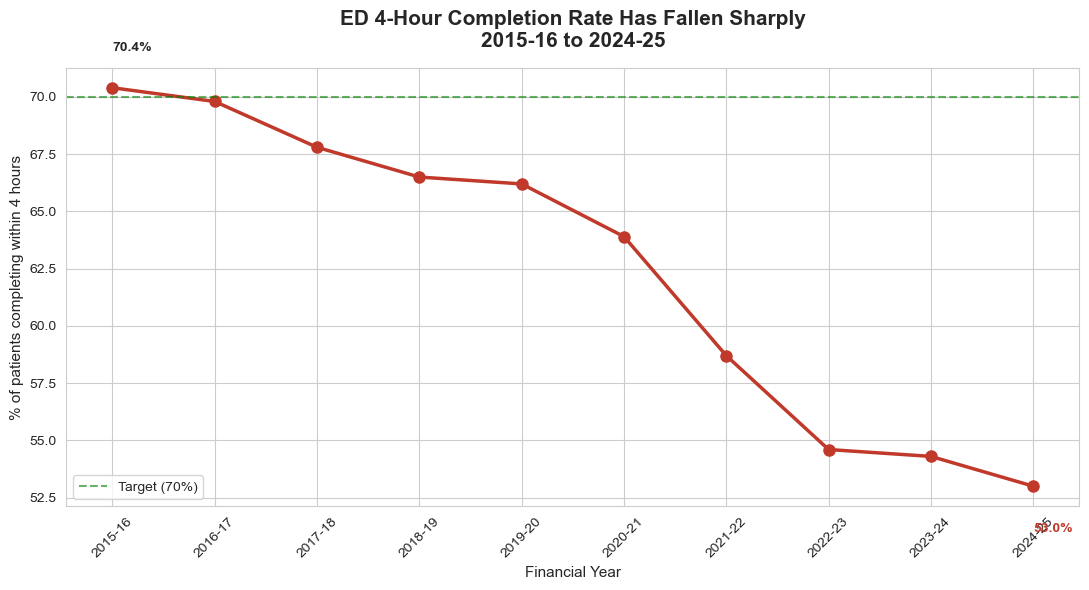

In [3]:
# Create the figure and axes
fig, ax = plt.subplots(figsize=(11, 6))

# Plot the line
ax.plot(trend['Year'], trend['avg_pct'], 
        marker='o', linewidth=2.5, color='#C0392B', markersize=8)

# Add a target reference line
ax.axhline(y=70, color='green', linestyle='--', alpha=0.6, 
           label='Target (70%)')

# Titles and labels
ax.set_title('ED 4-Hour Completion Rate Has Fallen Sharply\n2015-16 to 2024-25', 
             fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('% of patients completing within 4 hours', fontsize=11)
ax.set_xlabel('Financial Year', fontsize=11)

# Rotate x labels so they don't overlap
plt.xticks(rotation=45)

# Annotate the start and end values
ax.annotate('70.4%', xy=(0, 70.4), xytext=(0, 72), fontweight='bold')
ax.annotate('53.0%', xy=(9, 53.0), xytext=(9, 51), fontweight='bold', color='#C0392B')

ax.legend()
plt.tight_layout()
plt.show()

In [4]:
# Pull ED performance AND expenditure per state for 2023-24
query = """
SELECT 
    perf.StateName,
    perf.ed_rate,
    spend.expenditure
FROM
    (SELECT StateName, AVG(Value) AS ed_rate
     FROM fact_hospital_performance
     WHERE Measure = 'Patients staying for four hours or less'
       AND Description3 = 'ED stay length is within four hours'
       AND Unit = '%' AND Year = '2023-24'
       AND State NOT IN ('Total', 'Aust')
     GROUP BY StateName) AS perf
JOIN
    (SELECT StateName, SUM(Value) AS expenditure
     FROM fact_hospital_performance
     WHERE Measure = 'Recurrent expenditure'
       AND Unit = '$m' AND Year = '2023-24'
       AND State NOT IN ('Total', 'Aust')
     GROUP BY StateName) AS spend
ON perf.StateName = spend.StateName
"""

corr_data = pd.read_sql_query(query, conn)
corr_data

,StateName,ed_rate,expenditure
0,Australian Capital Territory,56.2,4324.0
1,New South Wales,57.4,59391.0
2,Northern Territory,55.3,3720.0
3,Queensland,51.9,43500.0
4,South Australia,50.8,13328.0
5,Tasmania,50.4,5642.0
6,Victoria,53.2,51372.0
7,Western Australia,59.1,24827.0


In [5]:
from scipy import stats

# Calculate Pearson correlation between expenditure and ED rate
correlation, p_value = stats.pearsonr(corr_data['expenditure'], corr_data['ed_rate'])

print(f"Correlation coefficient: {correlation:.3f}")
print(f"P-value: {p_value:.3f}")

Correlation coefficient: 0.174
P-value: 0.681


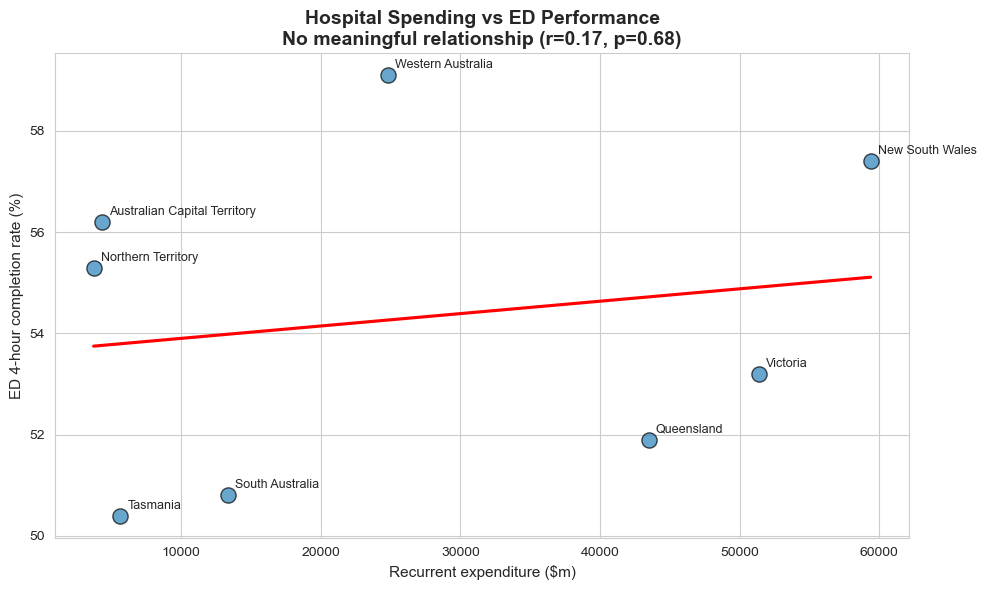

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot of the two variables
ax.scatter(corr_data['expenditure'], corr_data['ed_rate'], 
           s=120, color='#2980B9', alpha=0.7, edgecolors='black')

# Label each point with its state name
for i, row in corr_data.iterrows():
    ax.annotate(row['StateName'], 
                xy=(row['expenditure'], row['ed_rate']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

# Add a trend line to show the (weak) relationship
sns.regplot(data=corr_data, x='expenditure', y='ed_rate', 
            scatter=False, color='red', ax=ax, ci=None)

ax.set_title('Hospital Spending vs ED Performance\nNo meaningful relationship (r=0.17, p=0.68)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Recurrent expenditure ($m)', fontsize=11)
ax.set_ylabel('ED 4-hour completion rate (%)', fontsize=11)

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('hospital_analytics.db')

# Pull the ED and elective surgery data Tableau will use
query = """
SELECT Year, Measure, Description2, Description3, Unit, 
       State, StateName, Value
FROM fact_hospital_performance
WHERE Measure IN (
    'Patients staying for four hours or less',
    'Emergency department presentations',
    'Emergency department waiting times',
    'Elective surgery: waiting times'
)
AND State NOT IN ('Total', 'Aust')
"""

tableau_data = pd.read_sql_query(query, conn)
tableau_data.to_csv('tableau_hospital_data.csv', index=False)

print(f"Exported {len(tableau_data)} rows for Tableau")
tableau_data.head()

Exported 29576 rows for Tableau


,Year,Measure,Description2,Description3,Unit,State,StateName,Value
0,2024-25,Emergency department presentations,Emergency department,Presentations,no.,NSW,New South Wales,934737.0
1,2024-25,Emergency department presentations,Emergency department,Presentations,no.,NSW,New South Wales,1069033.0
2,2024-25,Emergency department presentations,Emergency department,Presentations,no.,NSW,New South Wales,547200.0
3,2024-25,Emergency department presentations,Emergency department,Presentations,no.,NSW,New South Wales,427883.0
4,2024-25,Emergency department presentations,Emergency department,Presentations,no.,NSW,New South Wales,181620.0


In [9]:
import os

# Show where the file was saved
print("Current folder:", os.getcwd())
print()
print("Is the CSV here?", os.path.exists('tableau_hospital_data.csv'))
print()
print("CSV files in this folder:")
for f in os.listdir():
    if f.endswith('.csv'):
        print("  ", f)

Current folder: C:\Users\manoj

Is the CSV here? True

CSV files in this folder:
   tableau_hospital_data.csv
